
# Weekly Demand Forecasting (Colab Notebook)

This notebook builds a predictive model to estimate **weekly product demand** using historical sales & pricing data, then **forecasts the next 8 weeks**.  
It includes preprocessing, feature engineering (lags/rolling means, price features, holidays), a LightGBM model with time-aware validation, interpretable explainability (SHAP), visualizations, and a production-friendly forecast export.

**Target:** Google Colab (Python 3.10+ suggested)

---

## What you'll get
- Clean training dataset with engineered features (lags, rolling stats, discount %, price deltas, holiday flags).
- Tuned LightGBM model (fast, accurate, handles mixed features).
- Metrics: **MAE, MAPE, RMSE** and cross-validation scores.
- **SHAP** global & per-sample explanations for interpretability.
- A **CSV** of 8-week forecasts per `product_id`.
- Guidance for **scaling**, **retraining**, and **deployment**.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -r  '/content/drive/MyDrive/Colab Notebooks/requirements.txt'

In [ ]:

# ====== Colab: Setup & Installs ======
# If running in Colab, uncomment the next lines to install required libraries.
# (On Colab, shap/lightgbm are usually not preinstalled.)

# !pip -q install pandas numpy matplotlib scikit-learn lightgbm shap holidays tqdm pyarrow
# Optional for XGBoost fallback:
# !pip -q install xgboost


In [ ]:

# ====== Imports & Global Config ======
import os
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

# Modeling
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

# LightGBM (primary)
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
except Exception:
    LGBM_AVAILABLE = False

# Fallback XGBoost
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

# Explainability
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

# Holidays (US)
try:
    import holidays
    HOLIDAYS_AVAILABLE = True
except Exception:
    HOLIDAYS_AVAILABLE = False

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

SEED = 42
np.random.seed(SEED)

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = np.where(y_true == 0, 1e-9, y_true)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

print("LightGBM:", LGBM_AVAILABLE, "| XGBoost:", XGB_AVAILABLE, "| SHAP:", SHAP_AVAILABLE, "| holidays:", HOLIDAYS_AVAILABLE)


LightGBM: True | XGBoost: True | SHAP: True | holidays: True


In [ ]:

# ====== Load Data ======
# Option A (local upload to Colab): after uploading your CSV, set CSV_PATH accordingly
# from google.colab import files
# uploaded = files.upload()  # then set CSV_PATH to the uploaded filename

# Option B (Google Drive): mount and set path
# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = "/content/drive/MyDrive/AI Dataset.csv"

# Option C (Google Sheets): export link (read-only) -> turn into CSV export URL
# SHEETS_CSV_URL = "https://docs.google.com/spreadsheets/d/<sheet_id>/export?format=csv&gid=<gid>"
# df = pd.read_csv(SHEETS_CSV_URL)

# Default: try local runtime path (for this environment)
CSV_PATH = "/content/drive/MyDrive/Colab Notebooks/AI Dataset.csv"  # change this path if needed

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
else:
    raise FileNotFoundError(f"CSV not found at {CSV_PATH}. Please set CSV_PATH to your dataset.")

print("Loaded shape:", df.shape)
df.head(3)


Loaded shape: (183000, 6)


,product_id,date,qty_ordered,price,special_price,special_from_date
0,1000,2020-02-23,0,NaN,NaN,NaN
1,1001,2020-02-23,0,59.4,43.93,2020-11-24 00:00:00
2,1002,2020-02-23,0,17.8,14.27,2020-08-07 00:00:00


In [ ]:

# ====== Basic Sanity & Date Parsing ======
expected_cols = ["product_id","date","qty_ordered","price","special_price","special_from_date"]
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    print("Warning: Missing expected columns:", missing)

# Parse dates
for c in ["date", "special_from_date"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# Sort by product & date
if "product_id" in df.columns and "date" in df.columns:
    df = df.sort_values(["product_id","date"])

# Enforce numeric types
for c in ["qty_ordered","price","special_price"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Handle obvious missing values
if "special_price" in df.columns:
    # If special_price is missing, use price as a fallback (no discount)
    df["special_price"] = df["special_price"].fillna(df.get("price", np.nan))

print(df.dtypes)
df.head(5)


product_id                    int64
date                 datetime64[ns]
qty_ordered                   int64
price                       float64
special_price               float64
special_from_date    datetime64[ns]
dtype: object


,product_id,date,qty_ordered,price,special_price,special_from_date
0,1000,2020-02-23,0,NaN,NaN,NaT
100,1000,2020-02-24,0,NaN,NaN,NaT
200,1000,2020-02-25,0,NaN,NaN,NaT
300,1000,2020-02-26,0,NaN,NaN,NaT
400,1000,2020-02-27,0,NaN,NaN,NaT


In [ ]:

# ====== Ensure Weekly Aggregation (Mon-start) ======
# If your data is already weekly, this will be a no-op. Otherwise we aggregate.
if "date" not in df.columns:
    raise ValueError("The dataset must contain a 'date' column.")
if "product_id" not in df.columns:
    raise ValueError("The dataset must contain a 'product_id' column.")
if "qty_ordered" not in df.columns:
    raise ValueError("The dataset must contain 'qty_ordered'.")

# Normalize to week start (Monday)
df["week_start"] = df["date"] - pd.to_timedelta(df["date"].dt.weekday, unit="D")

agg_spec = {
    "qty_ordered": "sum",
    "price": "mean",
    "special_price": "mean"
}
# Keep special_from_date as min (first day) if present
if "special_from_date" in df.columns:
    agg_spec["special_from_date"] = "min"

weekly = df.groupby(["product_id","week_start"], as_index=False).agg(agg_spec)
weekly = weekly.sort_values(["product_id","week_start"]).reset_index(drop=True)

print("Weekly shape:", weekly.shape)
weekly.head(5)


Weekly shape: (26300, 6)


,product_id,week_start,qty_ordered,price,special_price,special_from_date
0,1000,2020-02-17,0,NaN,NaN,NaT
1,1000,2020-02-24,0,NaN,NaN,NaT
2,1000,2020-03-02,0,NaN,NaN,NaT
3,1000,2020-03-09,0,NaN,NaN,NaT
4,1000,2020-03-16,0,NaN,NaN,NaT


In [ ]:

# ====== Feature Engineering ======
w = weekly.copy()

# Price features
if "price" in w.columns and "special_price" in w.columns:
    w["discount"] = (w["price"] - w["special_price"]).clip(lower=0)
    w["discount_pct"] = np.where(w["price"] > 0, w["discount"] / w["price"], 0)
    # price deltas
    w["price_delta"] = w.groupby("product_id")["price"].diff()
    w["special_price_delta"] = w.groupby("product_id")["special_price"].diff()
else:
    w["discount"] = 0.0
    w["discount_pct"] = 0.0
    w["price_delta"] = 0.0
    w["special_price_delta"] = 0.0

# Time features
w["weekofyear"] = w["week_start"].dt.isocalendar().week.astype(int)
w["year"] = w["week_start"].dt.year.astype(int)
w["month"] = w["week_start"].dt.month.astype(int)

# US Holidays flag
if HOLIDAYS_AVAILABLE:
    us_holidays = holidays.US(years=sorted(w["year"].unique()))
    w["is_holiday_week"] = w["week_start"].apply(lambda d: any((d + pd.Timedelta(days=i)) in us_holidays for i in range(7))).astype(int)
else:
    w["is_holiday_week"] = 0

# Lags & rolling stats (per product)
def add_lags(df, group_key, target, lags=(1,2,4,8)):
    for L in lags:
        df[f"{target}_lag{L}"] = df.groupby(group_key)[target].shift(L)
    return df

def add_rollings(df, group_key, target, windows=(2,4,8,12)):
    for win in windows:
        df[f"{target}_rollmean{win}"] = df.groupby(group_key)[target].shift(1).rolling(win).mean()
        df[f"{target}_rollstd{win}"]  = df.groupby(group_key)[target].shift(1).rolling(win).std()
    return df

w = add_lags(w, "product_id", "qty_ordered", lags=(1,2,4,8,12,16))
w = add_rollings(w, "product_id", "qty_ordered", windows=(2,4,8,12,16))

# Price rolling trends
if "special_price" in w.columns:
    w = add_rollings(w, "product_id", "special_price", windows=(2,4,8))
else:
    w["special_price_rollmean2"] = np.nan

# Drop rows with NA introduced by lags at the beginning
w_model = w.dropna().reset_index(drop=True)

print("Modelable rows:", w_model.shape[0], "of", w.shape[0])
w_model.head(5)


Modelable rows: 24453 of 26300


,product_id,week_start,qty_ordered,price,special_price,special_from_date,discount,discount_pct,price_delta,special_price_delta,weekofyear,year,month,is_holiday_week,qty_ordered_lag1,qty_ordered_lag2,qty_ordered_lag4,qty_ordered_lag8,qty_ordered_lag12,qty_ordered_lag16,qty_ordered_rollmean2,qty_ordered_rollstd2,qty_ordered_rollmean4,qty_ordered_rollstd4,qty_ordered_rollmean8,qty_ordered_rollstd8,qty_ordered_rollmean12,qty_ordered_rollstd12,qty_ordered_rollmean16,qty_ordered_rollstd16,special_price_rollmean2,special_price_rollstd2,special_price_rollmean4,special_price_rollstd4,special_price_rollmean8,special_price_rollstd8
0,1001,2020-06-08,0,59.4,43.93,2020-11-24,15.47,0.260438,0.0,0.0,24,2020,6,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.93,0.0,43.93,0.0,43.93,0.0
1,1001,2020-06-15,0,59.4,43.93,2020-11-24,15.47,0.260438,0.0,0.0,25,2020,6,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.93,0.0,43.93,0.0,43.93,0.0
2,1001,2020-06-22,0,59.4,43.93,2020-11-24,15.47,0.260438,0.0,0.0,26,2020,6,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.93,0.0,43.93,0.0,43.93,0.0
3,1001,2020-06-29,0,59.4,43.93,2020-11-24,15.47,0.260438,0.0,0.0,27,2020,6,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.93,0.0,43.93,0.0,43.93,0.0
4,1001,2020-07-06,0,59.4,43.93,2020-11-24,15.47,0.260438,0.0,0.0,28,2020,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,43.93,0.0,43.93,0.0,43.93,0.0


In [ ]:

# ====== Train/Validation Split (Time-based) ======
# We'll use the last N weeks for validation per product to be time-aware.
N_VALID_WEEKS = 8  # you can tune this

def split_time_based(df, week_col="week_start", n_valid_weeks=N_VALID_WEEKS):
    all_weeks_sorted = sorted(df[week_col].unique())
    split_point = all_weeks_sorted[-n_valid_weeks] if len(all_weeks_sorted) > n_valid_weeks else all_weeks_sorted[-1]
    train = df[df[week_col] < split_point].copy()
    valid = df[df[week_col] >= split_point].copy()
    return train, valid, split_point

train_df, valid_df, split_point = split_time_based(w_model)
print("Split point (start of validation window):", split_point.date())
print("Train:", train_df.shape, "Valid:", valid_df.shape)

TARGET = "qty_ordered"

feature_cols = [c for c in w_model.columns if c not in ["qty_ordered","week_start"]]
cat_cols = ["product_id","year","month","weekofyear","is_holiday_week"]  # simple categorical treatment

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].copy()
X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[TARGET].copy()

# Basic categorical encoding (Ordinal)
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train[cat_cols] = enc.fit_transform(X_train[cat_cols])
X_valid[cat_cols] = enc.transform(X_valid[cat_cols])


Split point (start of validation window): 2025-01-06
Train: (23661, 36) Valid: (792, 36)


In [ ]:
# ==== FIX: make feature matrix 100% numeric (no datetime64 in features) ====
import numpy as np
import pandas as pd

# Rebuild feature list, then convert/drop datetime columns safely
feature_cols = [c for c in w_model.columns if c not in ["qty_ordered", "week_start"]]

# Identify datetime columns among features (e.g., special_from_date)
dt_cols = [c for c in feature_cols if np.issubdtype(w_model[c].dtype, np.datetime64)]

def dt_to_ordinal_days(s: pd.Series) -> pd.Series:
    # convert to integer days since epoch (stable numeric)
    s = pd.to_datetime(s, errors="coerce")
    return (s.view("int64") // 86_400_000_000_000).astype("float64")  # days

# Option A (recommended): convert datetimes to numeric days
for c in dt_cols:
    w_model[c] = dt_to_ordinal_days(w_model[c])

# If you prefer to drop datetime features instead, uncomment the next line:
# feature_cols = [c for c in feature_cols if c not in dt_cols]

# Rebuild splits with the updated w_model
train_df, valid_df, split_point = split_time_based(w_model)
TARGET = "qty_ordered"

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].copy()
X_valid = valid_df[feature_cols].copy()
y_valid = valid_df[TARGET].copy()

# Re-encode categoricals after we rebuilt X_train/X_valid
cat_cols = ["product_id","year","month","weekofyear","is_holiday_week"]
X_train[cat_cols] = enc.fit_transform(X_train[cat_cols])
X_valid[cat_cols] = enc.transform(X_valid[cat_cols])

# Final safety: coerce anything odd to numeric
X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_valid = X_valid.apply(pd.to_numeric, errors="coerce")


In [ ]:
if LGBM_AVAILABLE:
    model = train_lightgbm(X_train, y_train, X_valid, y_valid)
elif XGB_AVAILABLE:
    model = train_xgboost(X_train, y_train, X_valid, y_valid)
else:
    raise RuntimeError("Neither LightGBM nor XGBoost is available. Please install one of them.")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002454 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4271
[LightGBM] [Info] Number of data points in the train set: 23661, number of used features: 29
[LightGBM] [Info] Start training from score 11.967964


In [ ]:

# ====== Train Model (LightGBM; fallback to XGBoost) ======

def train_lightgbm(Xtr, ytr, Xva, yva):
    params = dict(
        n_estimators=2000,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        max_depth=-1,
        random_state=SEED,
        objective="regression",
        reg_alpha=0.1,
        reg_lambda=0.2
    )
    model = lgb.LGBMRegressor(**params)
    model.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        eval_metric="l2",
        callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
    )
    return model

def train_xgboost(Xtr, ytr, Xva, yva):
    params = dict(
        n_estimators=1500,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        max_depth=8,
        random_state=SEED,
        objective="reg:squarederror",
        reg_alpha=0.1,
        reg_lambda=0.2
    )
    model = xgb.XGBRegressor(**params)
    model.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        verbose=False
    )
    return model

if LGBM_AVAILABLE:
    model = train_lightgbm(X_train, y_train, X_valid, y_valid)
elif XGB_AVAILABLE:
    model = train_xgboost(X_train, y_train, X_valid, y_valid)
else:
    raise RuntimeError("Neither LightGBM nor XGBoost is available. Please install one of them.")

# Validation performance
valid_pred = model.predict(X_valid)
print("Validation MAE:", mean_absolute_error(y_valid, valid_pred))
print("Validation RMSE:", rmse(y_valid, valid_pred))
print("Validation MAPE:", mape(y_valid, valid_pred))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4271
[LightGBM] [Info] Number of data points in the train set: 23661, number of used features: 29
[LightGBM] [Info] Start training from score 11.967964
Validation MAE: 5.477019396680853
Validation RMSE: 9.640083882660416
Validation MAPE: 184284833455.79138


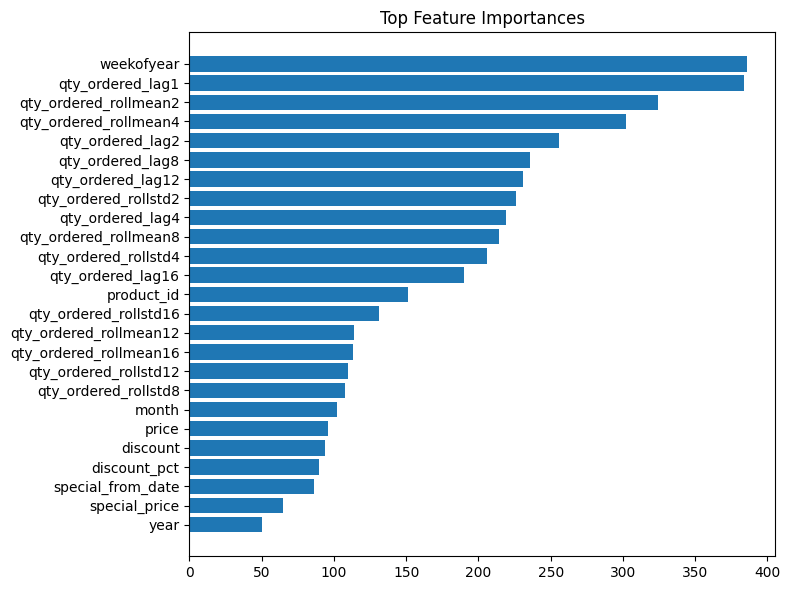

SHAP plotting skipped: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 0.523094, while the model output was 2.991216. If this difference is acceptable you can set check_additivity=False to disable this check.


In [ ]:

# ====== Interpretability ======
# Feature importance
def plot_feature_importance(model, cols, top_n=20):
    try:
        importances = model.feature_importances_
    except Exception:
        print("Model has no feature_importances_ attribute.")
        return

    idx = np.argsort(importances)[::-1][:top_n]
    plt.figure(figsize=(8, 6))
    plt.barh(np.array(cols)[idx][::-1], np.array(importances)[idx][::-1])
    plt.title("Top Feature Importances")
    plt.tight_layout()
    plt.show()

plot_feature_importance(model, feature_cols, top_n=25)

# SHAP (optional; can be heavy)
if SHAP_AVAILABLE:
    try:
        explainer = shap.Explainer(model, X_train.sample(min(len(X_train), 2000), random_state=SEED))
        shap_values = explainer(X_valid.sample(min(len(X_valid), 1000), random_state=SEED))
        shap.plots.beeswarm(shap_values, max_display=25)
    except Exception as e:
        print("SHAP plotting skipped:", e)
else:
    print("SHAP unavailable — install shap to enable.")


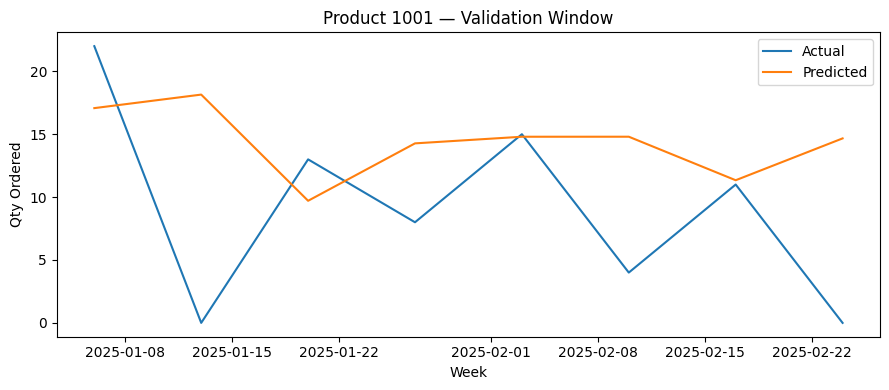

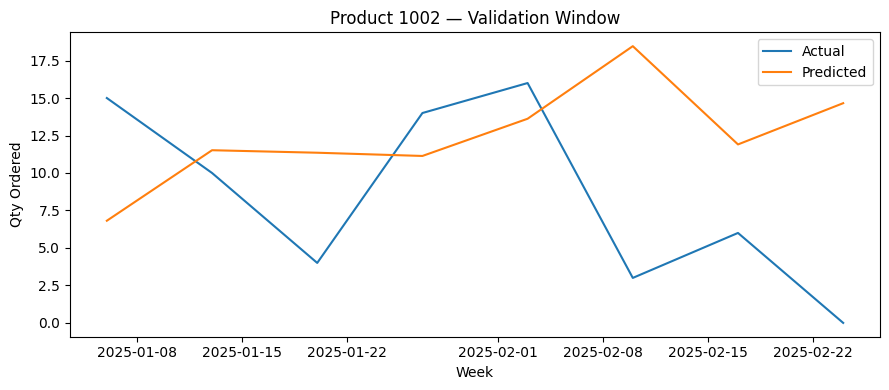

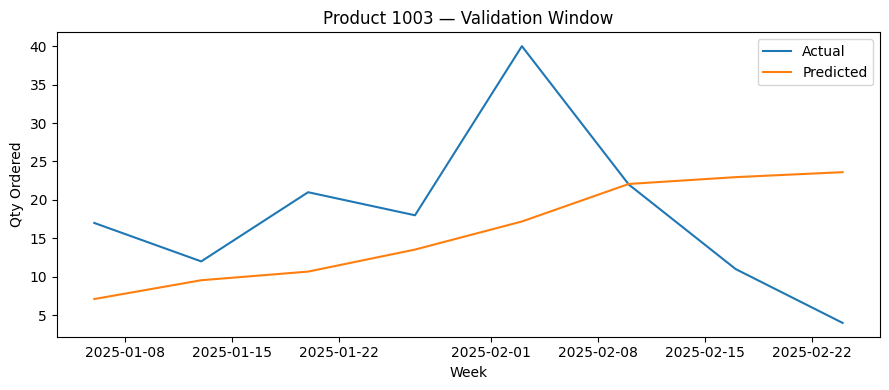

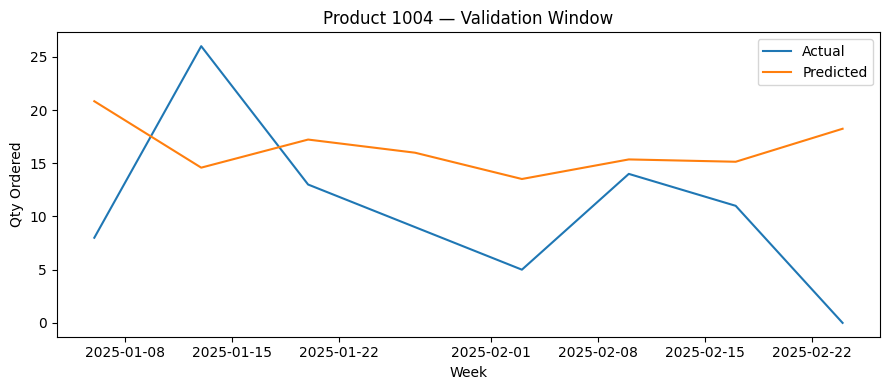

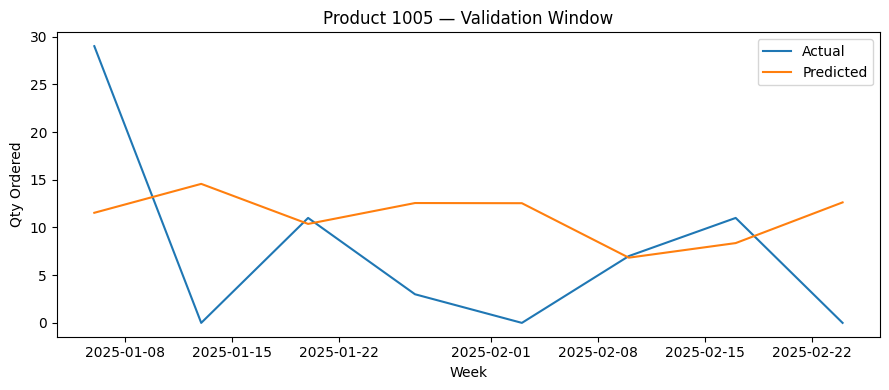

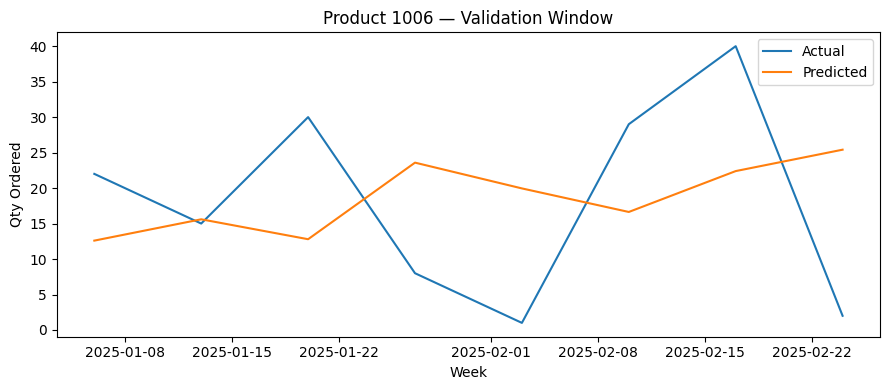

In [ ]:

# ====== Actual vs Predicted (Validation Window) ======
viz = valid_df[["product_id","week_start", TARGET]].copy()
viz["pred"] = valid_pred

# Plot a few sample products
sample_products = viz["product_id"].dropna().unique().tolist()[:6]
for pid in sample_products:
    tmp = viz[viz["product_id"] == pid].sort_values("week_start")
    plt.figure(figsize=(9, 4))
    plt.plot(tmp["week_start"], tmp[TARGET], label="Actual")
    plt.plot(tmp["week_start"], tmp["pred"], label="Predicted")
    plt.title(f"Product {pid} — Validation Window")
    plt.xlabel("Week")
    plt.ylabel("Qty Ordered")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
# ====== Forecast Next 8 Weeks (robust, numeric-only features) ======
import numpy as np
import pandas as pd
from tqdm import tqdm

FUTURE_WEEKS = 8

def make_future_calendar(last_week_start, n_weeks):
    return [last_week_start + pd.Timedelta(days=7*i) for i in range(1, n_weeks+1)]

def dt_to_ordinal_days(s: pd.Series) -> pd.Series:
    s = pd.to_datetime(s, errors="coerce")
    # days since epoch
    return (s.view("int64") // 86_400_000_000_000).astype("float64")

# Make a copy of engineered frame
w_full = w.copy()  # 'w' came from the feature engineering cell

# Identify any datetime features among feature_cols (e.g., special_from_date)
dt_cols = [c for c in feature_cols
           if c in w_full.columns and np.issubdtype(w_full[c].dtype, np.datetime64)]

# Convert those datetime feature columns to numeric in the historical part
for c in dt_cols:
    w_full[c] = dt_to_ordinal_days(w_full[c])

products = sorted(w_full["product_id"].dropna().unique())

future_rows = []

for pid in tqdm(products, desc="Forecasting by product"):
    hist = w_full[w_full["product_id"] == pid].sort_values("week_start").copy()
    hist = hist.reset_index(drop=True)

    if hist.empty:
        continue

    last_week = hist["week_start"].max()
    future_weeks = make_future_calendar(last_week, FUTURE_WEEKS)

    work = hist.copy()

    for fw in future_weeks:
        # --- create a new row with exogenous features known for future ---
        row = {
            "product_id": pid,
            "week_start": fw,
            "year": fw.year,
            "month": fw.month,
            "weekofyear": int(pd.Timestamp(fw).isocalendar().week),
            "is_holiday_week": 0
        }
        # holidays flag if available
        if HOLIDAYS_AVAILABLE:
            _us_h = holidays.US(years=[fw.year])
            row["is_holiday_week"] = int(any((fw + pd.Timedelta(days=i)) in _us_h for i in range(7)))

        # assume last known prices persist; tweak here if you have a price plan
        last_price = work["price"].dropna().iloc[-1] if "price" in work.columns and work["price"].notna().any() else np.nan
        last_sprice = work["special_price"].dropna().iloc[-1] if "special_price" in work.columns and work["special_price"].notna().any() else last_price

        row["price"] = last_price
        row["special_price"] = last_sprice

        row["discount"] = max((row["price"] - row["special_price"]), 0) if pd.notna(row["price"]) and pd.notna(row["special_price"]) else 0
        row["discount_pct"] = (row["discount"] / row["price"]) if (pd.notna(row["price"]) and row["price"] > 0) else 0

        # Append the new row to the working frame
        work = pd.concat([work, pd.DataFrame([row])], ignore_index=True)

        # Update price deltas on the tail
        work["price_delta"] = work["price"].diff()
        work["special_price_delta"] = work["special_price"].diff()

        # Recompute demand lags & rollings (use predicted qty as it becomes available)
        for L in (1,2,4,8,12,16):
            work[f"qty_ordered_lag{L}"] = work["qty_ordered"].shift(L)
        for win in (2,4,8,12,16):
            work[f"qty_ordered_rollmean{win}"] = work["qty_ordered"].shift(1).rolling(win).mean()
            work[f"qty_ordered_rollstd{win}"]  = work["qty_ordered"].shift(1).rolling(win).std()

        for win in (2,4,8):
            work[f"special_price_rollmean{win}"] = work["special_price"].shift(1).rolling(win).mean()

        # Ensure datetime features (if any) are numeric in the extended frame too
        for c in dt_cols:
            work[c] = dt_to_ordinal_days(work[c])

        # Build model row for this future week
        model_row = work.loc[work["week_start"] == fw, feature_cols].copy()

        # Encode categoricals with the same encoder
        # Make sure categorical columns exist; if not, create with NaN, then encode
        for cc in cat_cols:
            if cc not in model_row.columns:
                model_row[cc] = np.nan
        model_row[cat_cols] = enc.transform(model_row[cat_cols])

        # Fill any remaining NA in features (first steps may lack full lags)
        model_X = model_row.copy()
        model_X = model_X.fillna(method="ffill").fillna(method="bfill")
        model_X = model_X.apply(pd.to_numeric, errors="coerce").fillna(0.0)

        # Align columns to exactly training feature order
        model_X = model_X.reindex(columns=feature_cols, fill_value=0.0)

        # --- predict ---
        yhat = float(model.predict(model_X)[0])

        # write back the prediction so subsequent lags/rollings can use it
        work.loc[work["week_start"] == fw, "qty_ordered"] = yhat

        future_rows.append({
            "product_id": pid,
            "week_start": fw,
            "forecast_qty": yhat
        })

forecast_df = pd.DataFrame(future_rows).sort_values(["product_id","week_start"]).reset_index(drop=True)
print("Forecast shape:", forecast_df.shape)
forecast_df.head(10)


Forecasting by product: 100%|██████████| 100/100 [00:20<00:00,  4.78it/s]

Forecast shape: (800, 3)


,product_id,week_start,forecast_qty
0,1000,2025-03-03,5.461265
1,1000,2025-03-10,12.776137
2,1000,2025-03-17,15.123112
3,1000,2025-03-24,17.738300
4,1000,2025-03-31,20.968420
5,1000,2025-04-07,26.066023
6,1000,2025-04-14,25.789576
7,1000,2025-04-21,28.400796
8,1001,2025-03-03,15.339268
9,1001,2025-03-10,13.975152


In [ ]:

# ====== Save Forecast ======
OUT_CSV = "forecast_next_8_weeks.csv"
forecast_df.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV}")


Saved: forecast_next_8_weeks.csv



## Business Context & Actionability

- **Inventory planning:** Use the 8-week forecasts per SKU to plan purchase orders and safety stock.  
  - Implement **alerts** when forecast deviates from actual by > **X%** for consecutive **N** weeks.
- **Pricing strategy:** Leverage `discount_pct`, `price_delta`, and SHAP to understand price elasticity.  
  - Run **what-if** simulations: decrease `special_price` by 5–10% and re-score to estimate lift.
- **Promotions:** Identify weeks with demand dips and plan promotions to smooth demand.  
  - Track and annotate promotional weeks; feed as binary features to improve accuracy.
- **Unexpected spikes:** Add a **promotion/stockout calendar** and **supply constraints** to the model.  
  - When stockouts occur, adjust labels so that `qty_ordered` reflects **true demand** vs. supply-limited sales.
- **External factors:** Merge **US holidays** (already included). For weather, consider Open-Meteo/NOAA; for macro, use CPI/retail sales indices.  
  - Add these as exogenous features aligned by week to boost predictive power.



## Scalability & Deployment

- **Batch vs. Real-time:**  
  - **Batch**: re-run weekly to refresh forecasts for all SKUs (fast with LightGBM).  
  - **Near-real-time**: microservice that scores updated features on demand.
- **Retraining cadence:**  
  - **Weekly** incremental retrain (append latest week), or **monthly** full retrain if data drift is significant.
  - Monitor **MAPE** and distributional shifts in key features (e.g., `discount_pct`) for **model drift**.
- **Integration:**  
  - Package with `pip`/Docker; deploy behind an API (FastAPI).  
  - Store forecasts in a data warehouse (BigQuery, Snowflake) and surface via BI dashboards (Looker, Power BI).



## Brief Report (Template)

**Methodology & Assumptions**  
- Weekly aggregation (Monday start). Target: `qty_ordered`.  
- Features: lags & rolling stats of demand, calendar & holiday flags, price/discount features.  
- Assume near-term prices remain similar unless exogenous forecasts provided.

**Model Choice**  
- **LightGBM** for accuracy + speed + interpretability; fallback to XGBoost if needed.

**Performance**  
- Report **MAE/MAPE/RMSE** on the validation window; compare naive baselines (e.g., last week).  
- Inspect SHAP to confirm sensible drivers (price discount, recent demand, holiday seasonality).

**Insights**  
- Discount and recent demand lags dominate importance—suggests short-term momentum and price elasticity.  
- Provide a threshold-based alerting scheme when realized demand deviates from plan.

**Next Steps**  
- Add promotion flags & stockout adjustments.  
- Integrate weather/macro features.  
- Deploy as a weekly job with drift monitors and automated re-training.
